# DMS Analysis: SARS-CoV-2 Spike & Mpro — Standard Pipeline

This notebook computes per-mutation enrichment scores from deep mutational scanning (DMS) barcode count data and correlates them with evolutionary fitness estimates from Bloom & Neher (2023).

**Data sources:**
- Bloom & Neher fitness: `jbloomlab/SARS2-mut-fitness`
- Spike DMS counts: `dms-vep/SARS-CoV-2_Omicron_BA.1_spike_DMS_mAbs`
- Mpro DMS: Flynn et al. 2022, eLife 77433

In [1]:
# Import Library

import pandas as pd
import numpy as np
import re
import requests
from functools import reduce
import matplotlib.pyplot as plt
from scipy import stats

## 1. Imports

In [2]:
 # Load fitness estimates

url = ("https://raw.githubusercontent.com/jbloomlab/SARS2-mut-fitness"
       "/main/results/aa_fitness/aamut_fitness_all.csv")
fitness_df = pd.read_csv(url)

# Standardise column names to lowercase
fitness_df.columns = fitness_df.columns.str.lower()

# Filter to well-estimated mutations (>= 20 expected counts, as in Figure 4)
fitness_df = fitness_df[fitness_df['expected_count'] >= 20].copy()

print("Fitness df shape:", fitness_df.shape)
print(fitness_df.columns.tolist())
# Imp Columns: gene, aa_site, mutant_aa, delta_fitness

Fitness df shape: (88607, 12)
['gene', 'clade_founder_aa', 'mutant_aa', 'aa_site', 'aa_mutation', 'subset_of_orf1ab', 'expected_count', 'actual_count', 'count_terminal', 'count_non_terminal', 'mean_log_size', 'delta_fitness']


## 2. Load Bloom & Neher Fitness Estimates

Loads amino acid-level evolutionary fitness scores from Bloom & Neher (2023). Mutations with `expected_count < 20` are filtered out to retain only well-estimated values.

In [3]:

# Load spike barcode-variant lookup table

bv_url = ("https://raw.githubusercontent.com/dms-vep/"
          "SARS-CoV-2_Omicron_BA.1_spike_DMS_mAbs/main/"
          "results/variants/codon_variants.csv")
bv_table = pd.read_csv(bv_url)
print("Barcode table shape:", bv_table.shape)
print(bv_table.columns.tolist())
# Imp columns: barcode, library, aa_substitutions, n_aa_substitutions


Barcode table shape: (360141, 8)
['target', 'library', 'barcode', 'variant_call_support', 'codon_substitutions', 'aa_substitutions', 'n_codon_substitutions', 'n_aa_substitutions']


## 3. Load Spike Barcode-Variant Lookup Table

Maps each barcode sequence to its amino acid substitution(s) in the BA.1 spike library.

In [5]:
 #Load all variant count CSVs from GitHub URL

repo      = "dms-vep/SARS-CoV-2_Omicron_BA.1_spike_DMS_mAbs"
api_url   = f"https://api.github.com/repos/{repo}/contents/results/variant_counts"
raw_base  = f"https://raw.githubusercontent.com/{repo}/main/results/variant_counts/"

response = requests.get(api_url)
if response.status_code != 200:
    raise Exception(f"GitHub API error: {response.status_code}")

files = [f["name"] for f in response.json() if f["name"].endswith(".csv")]
print(f"Files found: {len(files)}")
print(files[:5], "...")

all_counts = []
for f in files:
    try:
        df = pd.read_csv(raw_base + f)
        df["sample_file"] = f
        all_counts.append(df)
    except Exception as e:
        print(f"  SKIP {f}: {e}")

counts_df = pd.concat(all_counts, ignore_index=True)
print("counts_df shape:", counts_df.shape)
print(counts_df["sample_file"].unique()[:5])

Files found: 37
['Lib-1_2022-03-25_thaw-1_VSVG_control_1.csv', 'Lib-1_2022-03-25_thaw-1_VSVG_control_2.csv', 'Lib-1_2022-04-13_thaw-1_antibody_LyCoV-1404_0.654_1.csv', 'Lib-1_2022-04-13_thaw-1_antibody_LyCoV-1404_0.654_2.csv', 'Lib-1_2022-04-13_thaw-1_antibody_LyCoV-1404_10.464_1.csv'] ...
counts_df shape: (4398804, 12)
['Lib-1_2022-03-25_thaw-1_VSVG_control_1.csv'
 'Lib-1_2022-03-25_thaw-1_VSVG_control_2.csv'
 'Lib-1_2022-04-13_thaw-1_antibody_LyCoV-1404_0.654_1.csv'
 'Lib-1_2022-04-13_thaw-1_antibody_LyCoV-1404_0.654_2.csv'
 'Lib-1_2022-04-13_thaw-1_antibody_LyCoV-1404_10.464_1.csv']


## 4. Download Variant Count Data

Fetches all per-sample barcode count CSVs from the dms-vep GitHub repository via the GitHub API, then concatenates them into a single long-format dataframe.

In [6]:

#  Split input vs output samples

# The input files are: 'VSVG_control_1.csv', 'VSVG_control_2.csv'

input_mask  = counts_df["sample_file"].str.contains("VSVG_control")
output_mask = counts_df["sample_file"].str.contains("no-antibody_control")

print("Input rows: ", input_mask.sum())
print("Output rows:", output_mask.sum())

# Verify  matched files
assert input_mask.sum()  > 0, "No VSVG_control files matched — check filenames"
assert output_mask.sum() > 0, "No no-antibody_control files matched — check filenames"

input_counts = (
    counts_df[input_mask]
    .groupby("barcode")["count"]
    .sum()
    .reset_index()
    .rename(columns={"count": "count_input"})
)
output_counts = (
    counts_df[output_mask]
    .groupby("barcode")["count"]
    .sum()
    .reset_index()
    .rename(columns={"count": "count_output"})
)
print("Input barcodes: ", len(input_counts))
print("Output barcodes:", len(output_counts))

Input rows:  454496
Output rows: 454496
Input barcodes:  354309
Output barcodes: 354309


## 5. Split Input vs Output Samples

- **Input:** `VSVG_control` samples — pseudovirus with VSV-G envelope (non-selective)
- **Output:** `no-antibody_control` samples — spike pseudovirus (functionally selected)

In [7]:

# Merge counts → barcode-variant table

merged = input_counts.merge(output_counts, on="barcode", how="inner")
merged = merged.merge(
    bv_table[["barcode", "library", "aa_substitutions", "n_aa_substitutions"]],
    on="barcode",
    how="inner"
)
print("Merged shape:", merged.shape)
# If this is 0, check that bv_table has a 'barcode' column
assert len(merged) > 0, (
    "Merge produced 0 rows.\n"
    "Check that bv_table columns include 'barcode': " + str(bv_table.columns.tolist())
)


Merged shape: (360141, 6)


## 6. Merge Counts with Barcode-Variant Table

Joins input and output counts on barcode, then attaches amino acid substitution annotations. Only barcodes present in both input and output are retained (inner join).

In [8]:

#  Single mutants → enrichment score → per-mutation mean

pseudocount = 0.5

single_muts = merged[merged["n_aa_substitutions"] == 1].copy()
print("Single mutants:", len(single_muts))

total_input  = single_muts["count_input"].sum()
total_output = single_muts["count_output"].sum()

single_muts["freq_input"]  = (single_muts["count_input"]  + pseudocount) / (total_input  + pseudocount)
single_muts["freq_output"] = (single_muts["count_output"] + pseudocount) / (total_output + pseudocount)
single_muts["log2_enrich"] = np.log2(single_muts["freq_output"] / single_muts["freq_input"])

spike_scores = (
    single_muts
    .groupby("aa_substitutions")["log2_enrich"]
    .agg(["mean", "count"])
    .reset_index()
    .rename(columns={"mean": "dms_score", "count": "n_barcodes"})
)


Single mutants: 102250


## 7. Compute Log₂ Enrichment Scores

For each single-mutant barcode, computes `log2(freq_out / freq_in)` with pseudocount correction (pseudocount = 0.5). Per-mutation scores are averaged across all barcodes carrying the same substitution.

In [9]:

# Normalise: wildtype = 0, stop = -1

wt   = merged[merged["n_aa_substitutions"] == 0].copy()
stop = merged[merged["aa_substitutions"].str.contains(r"\*", na=False)].copy()

for df in [wt, stop]:
    df["freq_input"]  = (df["count_input"]  + pseudocount) / (total_input  + pseudocount)
    df["freq_output"] = (df["count_output"] + pseudocount) / (total_output + pseudocount)
    df["log2_enrich"] = np.log2(df["freq_output"] / df["freq_input"])

wt_mean   = wt["log2_enrich"].mean()
stop_mean = stop["log2_enrich"].mean()

print(f"wt_mean={wt_mean:.4f}  stop_mean={stop_mean:.4f}")

spike_scores["dms_score_norm"] = (spike_scores["dms_score"] - wt_mean) / (wt_mean - stop_mean)
spike_scores = spike_scores[spike_scores["n_barcodes"] >= 3]
print("Spike mutations with scores:", len(spike_scores))
print(spike_scores.head())

wt_mean=0.0472  stop_mean=-5.3884
Spike mutations with scores: 6347
  aa_substitutions  dms_score  n_barcodes  dms_score_norm
0           *1250R   0.828210          32        0.143679
4           A1012Q  -4.062374           3       -0.756047
5           A1012S  -0.900924          12       -0.174431
6           A1012T  -2.926062          10       -0.546999
7           A1012V  -5.039513           7       -0.935813


## 8. Normalise Scores

Rescales enrichment scores so that:
- **Wildtype barcodes** (0 substitutions) → mean score of **0**
- **Stop codon variants** → mean score of **−1**

In [10]:

#  Parse mutation strings  e.g. 'N501Y' → site=501, mut_aa='Y'

def parse_mut(s):
    if pd.isna(s):
        return np.nan, np.nan, np.nan
    m = re.match(r'([A-Z])(\d+)([A-Z*])', str(s))
    if not m:
        return np.nan, np.nan, np.nan
    return m.group(1), int(m.group(2)), m.group(3)

parsed = spike_scores["aa_substitutions"].apply(parse_mut)
spike_scores["wt_aa"]  = parsed.apply(lambda x: x[0])
spike_scores["site"]   = parsed.apply(lambda x: x[1])
spike_scores["mut_aa"] = parsed.apply(lambda x: x[2])
spike_scores = spike_scores.dropna(subset=["site", "mut_aa"])
spike_scores["site"] = spike_scores["site"].astype(int)
print("After parsing:", spike_scores.shape)



After parsing: (6272, 7)


## 9. Parse Mutation Strings

Extracts structured fields from mutation strings (e.g. `N501Y` → `wt_aa=N`, `site=501`, `mut_aa=Y`).

In [11]:

#  Merge spike DMS with fitness data

bn_spike = fitness_df[
    fitness_df["gene"].astype(str).str.upper() == "S"
].copy()
bn_spike = bn_spike.rename(columns={
    "aa_site":      "site",
    "mutant_aa":    "mut_aa",
    "delta_fitness":"fitness"
})
bn_spike["site"] = pd.to_numeric(bn_spike["site"], errors="coerce").astype("Int64")

spike_comparison = spike_scores.merge(
    bn_spike[["site", "mut_aa", "fitness"]],
    on=["site", "mut_aa"],
    how="inner"
)
print("Spike overlap:", len(spike_comparison))
 


Spike overlap: 1855


## 10. Merge Spike DMS Scores with Evolutionary Fitness

Filters Bloom & Neher data to Spike (`gene == 'S'`) and merges on `(site, mut_aa)` to compare experimental DMS scores with evolutionary fitness estimates.

In [12]:

#  Mpro (Flynn et al. 2022)

from functools import reduce


mpro_url = "https://cdn.elifesciences.org/articles/77433/elife-77433-fig2-data1-v2.xlsx"
mpro_raw = pd.read_excel(mpro_url, sheet_name=None)

print("Sheets found:", list(mpro_raw.keys()))
for name, df in mpro_raw.items():
    print(f"\n--- Sheet: {repr(name)} ---")
    print("Columns:", df.columns.tolist())
    print(df.head(2).to_string())

Sheets found: ['FRET scores rep 1', 'FRET scores rep 2', 'TF scores rep 1', 'TF scores rep 2', 'Growth scores rep 1', 'Growth scores rep 2']

--- Sheet: 'FRET scores rep 1' ---
Columns: ['Position', ' aa', 'Counts (uncut)', 'Counts (cut)', 'functional score (unnormalized)', 'functional score (normalized)']
  Position  aa  Counts (uncut)  Counts (cut)  functional score (unnormalized)  functional score (normalized)
0       WT  WT            8239        129987                         0.907000                       1.000000
1        1   *            7190           364                         0.028296                      -0.004119

--- Sheet: 'FRET scores rep 2' ---
Columns: ['Position', ' aa', 'Counts (uncut)', 'Counts (cut)', 'functional score (unnormalized)', 'functional score (normalized)']
  Position  aa  Counts (uncut)  Counts (cut)  functional score (unnormalized)  functional score (normalized)
0       WT  WT           13478        166968                         0.890000            

## 11–12. Load Mpro DMS Data (Flynn et al. 2022)

Loads SARS-CoV-2 main protease (Mpro / NSP5) DMS data from the eLife supplementary files. Multiple assay sheets are concatenated and scores are averaged per mutation.

In [13]:

#  Mpro (Flynn et al. 2022) 



mpro_url = "https://cdn.elifesciences.org/articles/77433/elife-77433-fig2-data1-v2.xlsx"
mpro_raw = pd.read_excel(mpro_url, sheet_name=None)

print("Sheets:", list(mpro_raw.keys()))

assay_dfs = []

for sheet_name, df in mpro_raw.items():
    # Normalise column names for matching (strip whitespace, lowercase)
    col_map = {c: c.strip() for c in df.columns}
    df = df.rename(columns=col_map)
    col_lower = {c: c.lower() for c in df.columns}

    print(f"\n--- Sheet: {repr(sheet_name)} ---")
    print("  Columns:", df.columns.tolist())

    # ---- Find position column ----
    pos_col = next(
        (c for c in df.columns if col_lower[c] in ("position", "pos", "residue", "site")),
        None
    )
    if pos_col is None:
        print(f"  SKIP: no position column")
        continue

    # ---- Find mutation column ----
    mut_col = next(
        (c for c in df.columns if col_lower[c] in ("mutation", "mutant", "aa", "amino acid")),
        None
    )
    if mut_col is None:
        print(f"  SKIP: no mutation column")
        continue

    # ---- Find score column: prefer 'normalized', else 'score', else 'functional' ----
    score_col = next(
        (c for c in df.columns if "normaliz" in col_lower[c]),
        next(
            (c for c in df.columns
             if ("score" in col_lower[c] or "functional" in col_lower[c])
             and c not in (pos_col, mut_col)),
            None
        )
    )
    if score_col is None:
        print(f"  SKIP: no score column")
        continue

    print(f"  Using: pos={pos_col!r}, mut={mut_col!r}, score={score_col!r}")

    sub = df[[pos_col, mut_col, score_col]].copy()
    sub.columns = ["position", "mutation", sheet_name]
    sub = sub.dropna()
    sub["position"] = pd.to_numeric(sub["position"], errors="coerce")
    sub = sub.dropna(subset=["position"])
    sub["position"] = sub["position"].astype(int)
    # Ensure mutation is a clean uppercase string
    sub["mutation"] = sub["mutation"].astype(str).str.strip().str.upper()
    sub = sub[sub["mutation"].str.match(r'^[A-Z*]$')]  # single AA letter only

    assay_dfs.append(sub)
    print(f"  Added: {len(sub)} rows")


if len(assay_dfs) == 0:
    print("\nNo per-sheet data found. Trying wide-format (all assays in one sheet)...")
    
    # Find the sheet that has the most numeric columns
    best_sheet = max(mpro_raw.items(),
                     key=lambda kv: kv[1].select_dtypes(include='number').shape[1])
    sheet_name, df = best_sheet
    df = df.rename(columns={c: c.strip() for c in df.columns})
    print(f"Using sheet {repr(sheet_name)}, columns: {df.columns.tolist()}")

    col_lower = {c: c.lower() for c in df.columns}

    pos_col = next(
        (c for c in df.columns if col_lower[c] in ("position", "pos", "residue", "site")),
        None
    )
    mut_col = next(
        (c for c in df.columns if col_lower[c] in ("mutation", "mutant", "aa")),
        None
    )

    if pos_col is None or mut_col is None:
        raise ValueError(
            f"Cannot find position/mutation columns.\n"
            f"Columns in best sheet: {df.columns.tolist()}"
        )

    # All remaining numeric columns are assay scores
    score_cols = [c for c in df.columns
                  if c not in (pos_col, mut_col)
                  and pd.api.types.is_numeric_dtype(df[c])]
    print(f"Score columns: {score_cols}")

    df = df[[pos_col, mut_col] + score_cols].copy()
    df.columns = ["position", "mutation"] + score_cols
    df = df.dropna()
    df["position"] = pd.to_numeric(df["position"], errors="coerce")
    df = df.dropna(subset=["position"])
    df["position"] = df["position"].astype(int)
    df["mutation"] = df["mutation"].astype(str).str.strip().str.upper()
    df = df[df["mutation"].str.match(r'^[A-Z*]$')]

    merged_mpro = df.copy()
    score_cols_final = score_cols

else:
    # Merge all per-sheet assay DataFrames on position + mutation
    merged_mpro = reduce(
        lambda a, b: pd.merge(a, b, on=["position", "mutation"], how="inner"),
        assay_dfs
    )
    score_cols_final = [c for c in merged_mpro.columns
                        if c not in ("position", "mutation")]

merged_mpro["dms_score_avg"] = merged_mpro[score_cols_final].mean(axis=1)
print("\nMpro merged shape:", merged_mpro.shape)
print(merged_mpro.head())

Sheets: ['FRET scores rep 1', 'FRET scores rep 2', 'TF scores rep 1', 'TF scores rep 2', 'Growth scores rep 1', 'Growth scores rep 2']

--- Sheet: 'FRET scores rep 1' ---
  Columns: ['Position', 'aa', 'Counts (uncut)', 'Counts (cut)', 'functional score (unnormalized)', 'functional score (normalized)']
  Using: pos='Position', mut='aa', score='functional score (unnormalized)'
  Added: 6046 rows

--- Sheet: 'FRET scores rep 2' ---
  Columns: ['Position', 'aa', 'Counts (uncut)', 'Counts (cut)', 'functional score (unnormalized)', 'functional score (normalized)']
  Using: pos='Position', mut='aa', score='functional score (unnormalized)'
  Added: 6039 rows

--- Sheet: 'TF scores rep 1' ---
  Columns: ['Position', 'aa', 'Counts (uncut)', 'Counts (cut)', 'functional score (unnormalized)', 'functional score (normalized)', 'Unnamed: 6']
  Using: pos='Position', mut='aa', score='functional score (unnormalized)'
  Added: 6008 rows

--- Sheet: 'TF scores rep 2' ---
  Columns: ['Position', 'aa', 'Co

In [14]:

#  Merge Mpro DMS with fitness data


# 1: See all gene labels 
print("All gene labels:", fitness_df["gene"].unique())

#  2: Filter — catches nsp5, Mpro, NSP5, nsp5 (Mpro), etc.
mpro_mask = fitness_df["gene"].astype(str).str.lower().str.contains("nsp5|mpro")
bn_mpro = fitness_df[mpro_mask].copy()

print(f"bn_mpro rows: {len(bn_mpro)}")          # Must be > 0
print("Gene values matched:", bn_mpro["gene"].unique())

if len(bn_mpro) == 0:
    #  print all genes so you can see exactly what to use
    raise ValueError(
        "Still 0 rows. Gene labels in fitness_df:\n" +
        str(fitness_df["gene"].value_counts().to_string())
    )

# 3: Rename and type-cast
bn_mpro = bn_mpro.rename(columns={
    "aa_site":       "position",
    "mutant_aa":     "mutation",
    "delta_fitness": "fitness"
})
bn_mpro["position"] = pd.to_numeric(bn_mpro["position"], errors="coerce")
bn_mpro = bn_mpro.dropna(subset=["position"])
bn_mpro["position"] = bn_mpro["position"].astype(int)
bn_mpro["mutation"] = bn_mpro["mutation"].astype(str).str.strip().str.upper()

print("position range:", bn_mpro["position"].min(), "to", bn_mpro["position"].max())
print("mutation sample:", sorted(bn_mpro["mutation"].unique())[:10])

#  4: Merge
mpro_comparison = merged_mpro.merge(
    bn_mpro[["position", "mutation", "fitness"]],
    on=["position", "mutation"],
    how="inner"
)
print("Mpro overlap:", len(mpro_comparison))


All gene labels: ['E' 'M' 'N' 'ORF10' 'ORF1ab' 'ORF3a' 'ORF6' 'ORF7a' 'ORF7b' 'ORF8'
 'ORF9b' 'S' 'nsp1' 'nsp10' 'nsp12 (RdRp)' 'nsp13' 'nsp14' 'nsp15' 'nsp16'
 'nsp2' 'nsp3' 'nsp4' 'nsp5 (Mpro)' 'nsp6' 'nsp7' 'nsp8' 'nsp9']
bn_mpro rows: 1599
Gene values matched: ['nsp5 (Mpro)']
position range: 1 to 306
mutation sample: ['*', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K']
Mpro overlap: 1279


## 13. Merge Mpro DMS Scores with Evolutionary Fitness

Filters Bloom & Neher data to Mpro (gene labels `nsp5`/`mpro`) and merges with Flynn et al. experimental scores.

  Spike protein: r=0.258, n=1855
  Mpro (nsp5): r=0.562, n=1279


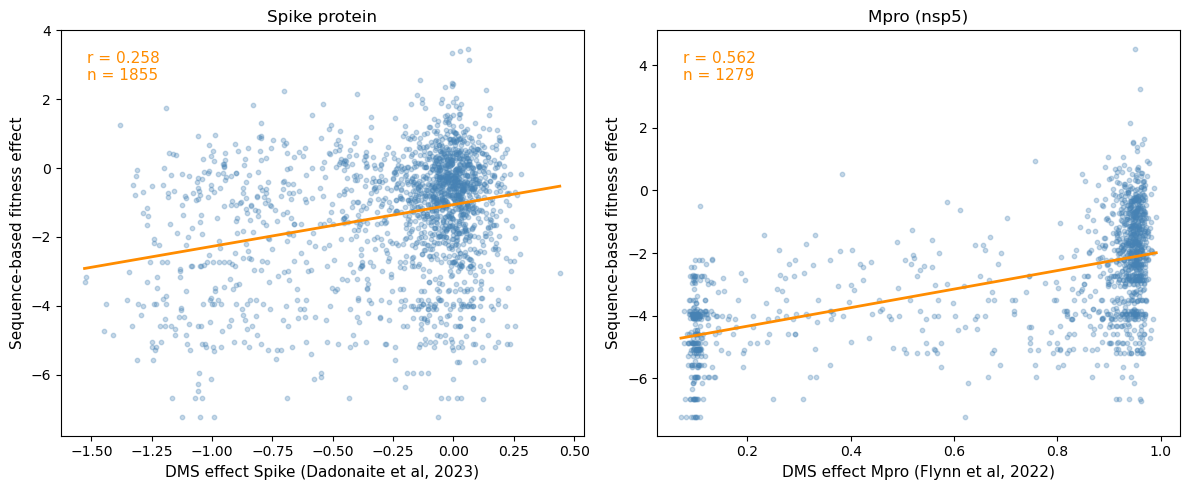

In [15]:

#  Plot Figure 4

def safe_panel(ax, x_vals, y_vals, title, xlabel, ylabel):
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        ax.text(0.5, 0.5, f"NO DATA (n={len(x)})", transform=ax.transAxes,
                ha="center", va="center", fontsize=12, color="red")
        ax.set_title(title + " — NO DATA")
        return

    r, _ = stats.pearsonr(x, y)
    ax.scatter(x, y, alpha=0.3, s=10, color="steelblue")
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, color="darkorange", linewidth=2)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f"r = {r:.3f}\nn = {len(x)}",
            transform=ax.transAxes, va="top", color="darkorange", fontsize=11)
    print(f"  {title}: r={r:.3f}, n={len(x)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

safe_panel(
    axes[0],
    spike_comparison["dms_score_norm"],
    spike_comparison["fitness"],
    "Spike protein",
    "DMS effect Spike (Dadonaite et al, 2023)",
    "Sequence-based fitness effect"
)

safe_panel(
    axes[1],
    mpro_comparison["dms_score_avg"],
    mpro_comparison["fitness"],
    "Mpro (nsp5)",
    "DMS effect Mpro (Flynn et al, 2022)",
    "Sequence-based fitness effect"
)

plt.tight_layout()
plt.savefig("figure4_reproduction.pdf", dpi=300, bbox_inches="tight")
plt.savefig("figure4_reproduction.png", dpi=300, bbox_inches="tight")
plt.show()

# Expected from paper:
#   Spike (Dadonaite): r ~ 0.664
#   Mpro (Flynn):      r ~ 0.528


## 14. Figure 4: DMS Score vs Evolutionary Fitness

Two-panel scatter plot:
- **Left:** Spike DMS (this study) vs Bloom & Neher Spike fitness
- **Right:** Mpro DMS (Flynn et al.) vs Bloom & Neher Mpro fitness

Pearson *r* and *p*-value are annotated on each panel.

##  Sensitivity Analysis : `expected_count` Filter Threshold

 the Pearson correlation between DMS scores and Bloom & Neher fitness changes under different filter thresholds (5, 10, 20),  the threshold chosen above.

In [17]:
# ============================================================
# Sensitivity Analysis: compare filter thresholds
# ============================================================

thresholds = [5, 10, 20]
results = []

for threshold in thresholds:
    # Filter at this threshold
    df_filtered = fitness_df_raw[fitness_df_raw['expected_count'] >= threshold].copy()
    
    # Merge with Spike scores
    bn_spike_t = df_filtered[df_filtered["gene"].astype(str).str.upper() == "S"].copy()
    bn_spike_t = bn_spike_t.rename(columns={"aa_site": "site", "mutant_aa": "mut_aa", "delta_fitness": "fitness"})
    bn_spike_t["site"] = pd.to_numeric(bn_spike_t["site"], errors="coerce").astype("Int64")
    
    spike_comp_t = spike_scores.merge(bn_spike_t[["site", "mut_aa", "fitness"]], on=["site", "mut_aa"], how="inner")
    
    # Merge with Mpro scores
    bn_mpro_t = df_filtered[df_filtered["gene"].astype(str).str.lower().str.contains("nsp5|mpro")].copy()
    bn_mpro_t = bn_mpro_t.rename(columns={"aa_site": "position", "mutant_aa": "mutation", "delta_fitness": "fitness"})
    bn_mpro_t["position"] = pd.to_numeric(bn_mpro_t["position"], errors="coerce").astype(int)
    
    mpro_comp_t = merged_mpro.merge(bn_mpro_t[["position", "mutation", "fitness"]], on=["position", "mutation"], how="inner")
    
    # Calculate correlations
    r_spike, _ = stats.pearsonr(spike_comp_t["dms_score_norm"], spike_comp_t["fitness"])
    r_mpro,  _ = stats.pearsonr(mpro_comp_t["dms_score_avg"],  mpro_comp_t["fitness"])
    
    results.append({
        "threshold": threshold,
        "spike_n":   len(spike_comp_t),
        "spike_r":   round(r_spike, 3),
        "mpro_n":    len(mpro_comp_t),
        "mpro_r":    round(r_mpro, 3)
    })
    print(f"Threshold ≥ {threshold}: Spike r={r_spike:.3f} (n={len(spike_comp_t)})  |  Mpro r={r_mpro:.3f} (n={len(mpro_comp_t)})")

results_df = pd.DataFrame(results)
print("\n", results_df)

Threshold ≥ 5: Spike r=0.238 (n=2529)  |  Mpro r=0.505 (n=1841)
Threshold ≥ 10: Spike r=0.244 (n=2472)  |  Mpro r=0.505 (n=1837)
Threshold ≥ 20: Spike r=0.258 (n=1855)  |  Mpro r=0.562 (n=1279)

    threshold  spike_n  spike_r  mpro_n  mpro_r
0          5     2529    0.238    1841   0.505
1         10     2472    0.244    1837   0.505
2         20     1855    0.258    1279   0.562
